# Pothole Detection — Pawar et al. (2020) Methodology

### Paper: "Efficient pothole detection using smartphone sensors"
**Authors:** Kshitij Pawar, Siddhi Jagtap, Smita Bhoir  
**Published:** ITM Web of Conferences 32, 03013 (2020), ICACC-2020

### Methodology Replication:
1. **Data**: Accelerometer X, Y, Z from smartphone (India_Data dataset)
2. **Grouping**: 2-second sliding windows
3. **Features (per axis)**: Min, Max, Mean, StdDev → 12 features from 3 accel axes  
   *(Paper used 24 features with gyroscope; India dataset has accel only)*
4. **Scaling**: Z-score standardization: `x = (x - mean) / std`
5. **Model**: Neural Network — 2 hidden layers (Dense + Dropout) + sigmoid output
6. **Training**: Binary cross-entropy, 140 epochs, batch size 3
7. **Target**: 94.78% accuracy, 0.71 precision, 0.81 recall (paper results)

### Dataset Note:
The India_Data has only **accelerometer** (no gyroscope), so we adapt with 12 features instead of 24.  
We also add **Total Acceleration Magnitude** features (4 more) → **16 features total**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
print('Ready.')

C:\Users\Devyansh\AppData\Roaming\Python\Python312\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


PyTorch 2.6.0+cpu | Device: cpu
Ready.


## 1. Load India Dataset (All 10 Trips)

In [2]:
DATA_ROOT = os.path.join('..', 'India_Data', 'Pathole_Road')

all_dfs = []
for trip_id in range(1, 11):
    path = os.path.join(DATA_ROOT, str(trip_id), 'acceleration_data_with_images.xlsx')
    df = pd.read_excel(path)
    df.columns = ['sno', 'time', 'X', 'Y', 'Z', 'label']
    
    # Binary label: 1 = pothole, 0 = normal
    df['is_pothole'] = (~df['label'].isin(['Not Detected', None]) & df['label'].notna()).astype(int)
    df['trip'] = trip_id
    
    n_pothole = df['is_pothole'].sum()
    n_normal = len(df) - n_pothole
    print(f'Trip {trip_id:2d}: {len(df):4d} samples | Pothole: {n_pothole:3d} | Normal: {n_normal:3d}')
    all_dfs.append(df)

raw_data = pd.concat(all_dfs, ignore_index=True)
print(f'\nTotal: {len(raw_data)} samples | Pothole: {raw_data["is_pothole"].sum()} | Normal: {(1-raw_data["is_pothole"]).sum()}')
print(f'Class imbalance: {raw_data["is_pothole"].mean()*100:.1f}% pothole')

Trip  1:  407 samples | Pothole:   8 | Normal: 399
Trip  2:  399 samples | Pothole:  11 | Normal: 388
Trip  3:  426 samples | Pothole:   7 | Normal: 419
Trip  4:  417 samples | Pothole:  12 | Normal: 405
Trip  5:  399 samples | Pothole:  12 | Normal: 387
Trip  6:  300 samples | Pothole:  18 | Normal: 282
Trip  7:  462 samples | Pothole:   7 | Normal: 455
Trip  8:  347 samples | Pothole:  12 | Normal: 335
Trip  9:  406 samples | Pothole:  14 | Normal: 392
Trip 10:  405 samples | Pothole:  14 | Normal: 391

Total: 3968 samples | Pothole: 115 | Normal: 3853
Class imbalance: 2.9% pothole


## 2. Explore Raw Accelerometer Data

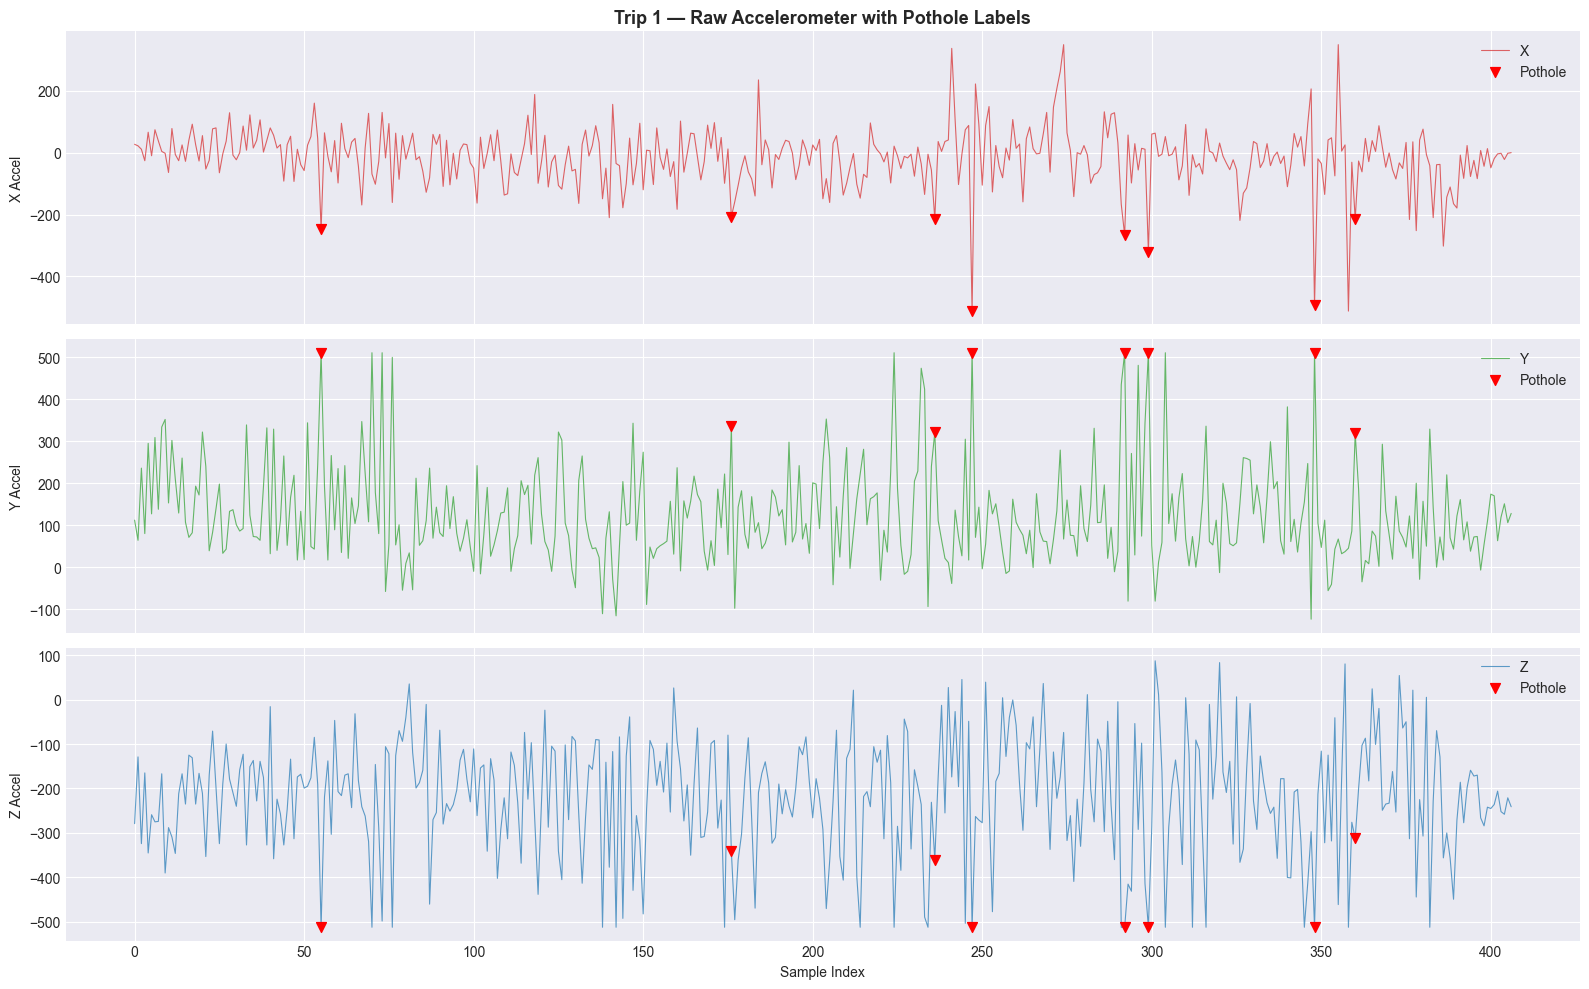


Raw accelerometer stats:
                 X            Y            Z
count  3968.000000  3968.000000  3968.000000
mean    -16.506048   132.226058  -216.136341
std      98.176264   136.144099   131.855240
min    -512.000000  -512.000000  -512.000000
25%     -63.000000    44.000000  -292.000000
50%     -12.000000   105.000000  -212.500000
75%      38.000000   194.000000  -127.000000
max     511.000000   511.000000   228.000000


In [3]:
# Show a couple of trips with pothole markers
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

trip_df = raw_data[raw_data['trip'] == 1].reset_index(drop=True)
for ax, col, color in zip(axes, ['X', 'Y', 'Z'], ['tab:red', 'tab:green', 'tab:blue']):
    ax.plot(trip_df.index, trip_df[col], color=color, lw=0.8, alpha=0.7, label=col)
    # Mark potholes
    ph = trip_df[trip_df['is_pothole'] == 1]
    ax.scatter(ph.index, ph[col], color='red', s=50, zorder=5, marker='v', label='Pothole')
    ax.set_ylabel(f'{col} Accel')
    ax.legend(loc='upper right')

axes[0].set_title('Trip 1 — Raw Accelerometer with Pothole Labels', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Sample Index')
plt.tight_layout()
plt.show()

# Stats
print('\nRaw accelerometer stats:')
print(raw_data[['X', 'Y', 'Z']].describe())

## 3. Feature Engineering — 2-Second Windows (Pawar et al. §3.2.1)

From the paper:
> *"Each instance of the dataset was originally taken every fifth of a second, which resulted in turbulent fluctuations. Hence, in an attempt to counter this the instances were grouped by intervals of two seconds each, in order to make better sense of the data points."*

**Features per window (per axis):**
- Minimum
- Maximum  
- Mean
- Standard Deviation

**Axes:** Accel X, Y, Z + Total Magnitude  
**Total features:** 4 axes × 4 stats = **16 features**  
*(Paper had 6 axes × 4 stats = 24 features with gyroscope)*

**Window label:** Pothole if ANY sample in the window is labeled as pothole.

In [4]:
WINDOW_SECONDS = 2  # Pawar et al.: 2-second windows

def create_windows(trip_df, window_sec=WINDOW_SECONDS):
    """
    Group samples into 2-second windows based on the Time column.
    Extract Min, Max, Mean, StdDev for each axis.
    Label = 1 if ANY sample in the window is a pothole.
    """
    # Parse time to get seconds elapsed
    times = pd.to_datetime(trip_df['time'], format='%H:%M:%S')
    trip_df = trip_df.copy()
    trip_df['time_sec'] = (times - times.iloc[0]).dt.total_seconds()
    
    # Total acceleration magnitude
    trip_df['mag'] = np.sqrt(trip_df['X']**2 + trip_df['Y']**2 + trip_df['Z']**2)
    
    max_t = trip_df['time_sec'].max()
    windows = []
    
    t = 0.0
    while t + window_sec <= max_t + 1:  # +1 to include last window
        mask = (trip_df['time_sec'] >= t) & (trip_df['time_sec'] < t + window_sec)
        w = trip_df[mask]
        
        if len(w) < 3:  # skip very sparse windows
            t += window_sec
            continue
        
        row = {}
        for axis in ['X', 'Y', 'Z', 'mag']:
            vals = w[axis].values.astype(float)
            row[f'{axis}_min'] = vals.min()
            row[f'{axis}_max'] = vals.max()
            row[f'{axis}_mean'] = vals.mean()
            row[f'{axis}_std'] = vals.std() if len(vals) > 1 else 0.0
        
        # Label: pothole if ANY sample in window is pothole
        row['is_pothole'] = int(w['is_pothole'].max())
        row['n_samples'] = len(w)
        row['trip'] = int(w['trip'].iloc[0])
        row['window_start'] = t
        
        windows.append(row)
        t += window_sec
    
    return pd.DataFrame(windows)


# Process all trips
all_windows = []
for trip_id in range(1, 11):
    trip_df = raw_data[raw_data['trip'] == trip_id].copy()
    w = create_windows(trip_df)
    all_windows.append(w)
    n_ph = w['is_pothole'].sum()
    print(f'Trip {trip_id:2d}: {len(w):3d} windows | Pothole: {n_ph:2d} | Normal: {len(w)-n_ph:3d}')

windowed = pd.concat(all_windows, ignore_index=True)
print(f'\nTotal windows: {len(windowed)}')
print(f'Pothole windows: {windowed["is_pothole"].sum()} ({windowed["is_pothole"].mean()*100:.1f}%)')
print(f'Normal windows: {(1-windowed["is_pothole"]).sum()}')
print(f'Avg samples per window: {windowed["n_samples"].mean():.1f}')

Trip  1:  21 windows | Pothole:  8 | Normal:  13
Trip  2:  21 windows | Pothole: 10 | Normal:  11
Trip  3:  22 windows | Pothole:  6 | Normal:  16
Trip  4:  24 windows | Pothole: 11 | Normal:  13
Trip  5:  22 windows | Pothole:  9 | Normal:  13
Trip  6:  19 windows | Pothole: 16 | Normal:   3
Trip  7:  25 windows | Pothole:  6 | Normal:  19
Trip  8:  18 windows | Pothole:  8 | Normal:  10
Trip  9:  22 windows | Pothole: 10 | Normal:  12
Trip 10:  23 windows | Pothole: 14 | Normal:   9

Total windows: 217
Pothole windows: 98 (45.2%)
Normal windows: 119
Avg samples per window: 18.2


## 4. Visualize Windowed Features — Pothole vs Normal

From Pawar et al. (Figures 5 & 6):  
> *"The plots show the accelerometer standard deviations for the Good Road and Bad Road Intervals. The sharp spikes for the pothole occurrences can now be better perceived."*

Feature columns (16):
['X_min', 'X_max', 'X_mean', 'X_std', 'Y_min', 'Y_max', 'Y_mean', 'Y_std', 'Z_min', 'Z_max', 'Z_mean', 'Z_std', 'mag_min', 'mag_max', 'mag_mean', 'mag_std']


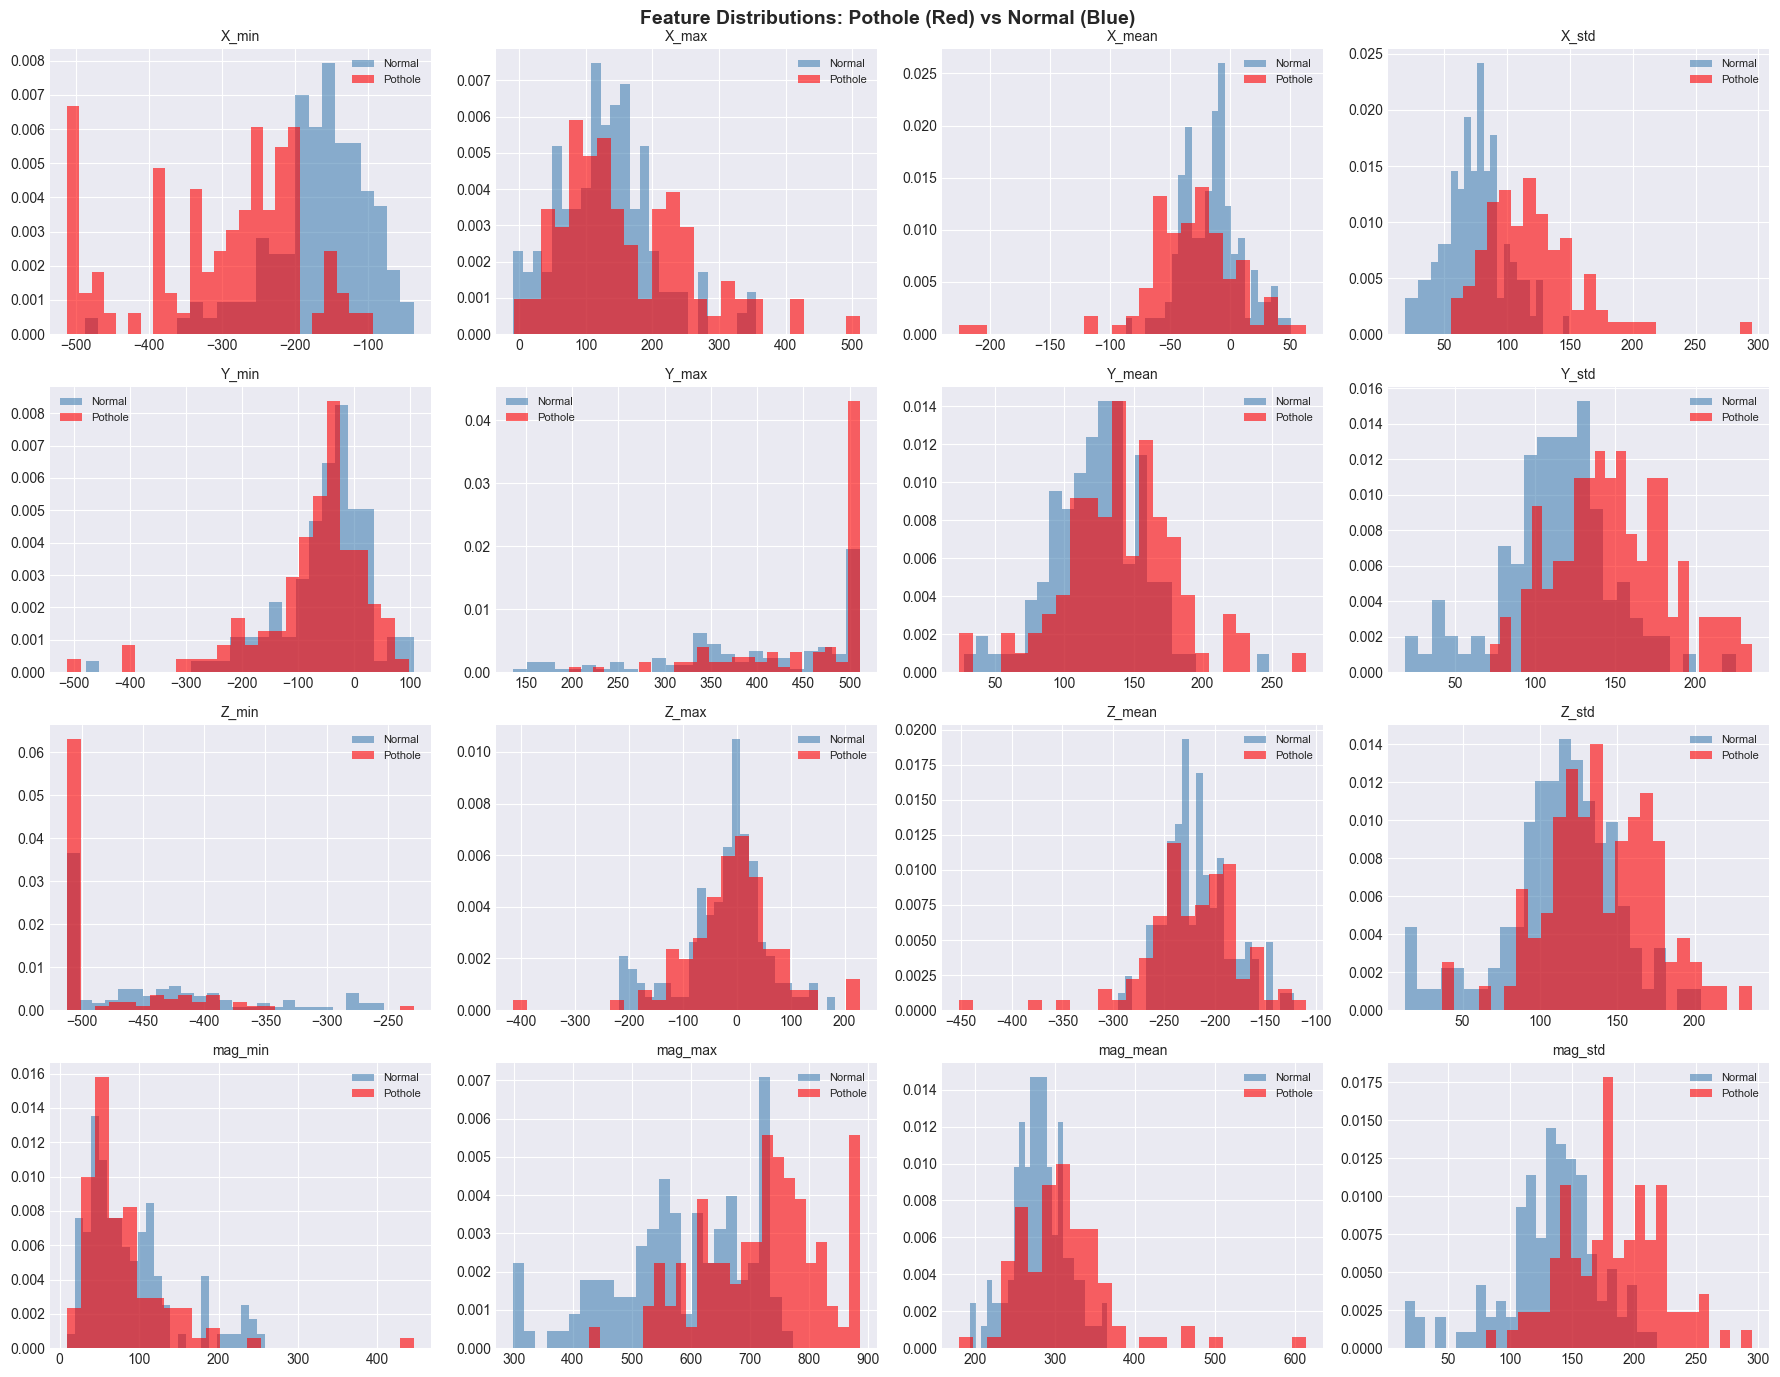

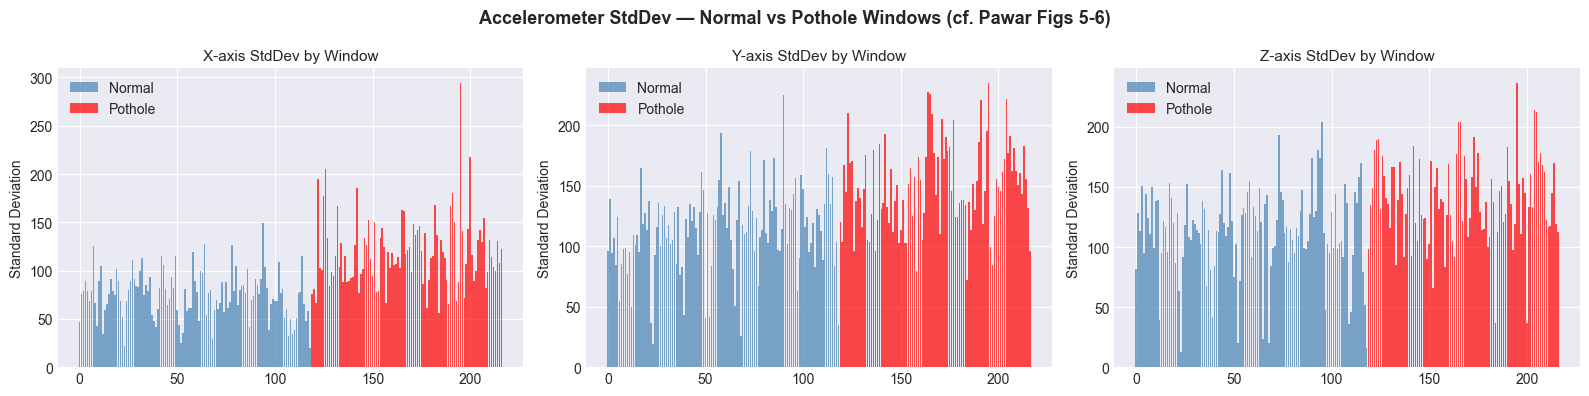

In [5]:
feature_cols = [c for c in windowed.columns if c.endswith(('_min', '_max', '_mean', '_std'))]
print(f'Feature columns ({len(feature_cols)}):')
print(feature_cols)

# Compare distributions: pothole vs normal
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.ravel(), feature_cols):
    for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'red', 'Pothole')]:
        subset = windowed[windowed['is_pothole'] == label][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions: Pothole (Red) vs Normal (Blue)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show StdDev comparison like Pawar Figures 5 & 6
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, axis in zip(axes, ['X', 'Y', 'Z']):
    normal = windowed[windowed['is_pothole'] == 0]
    pothole = windowed[windowed['is_pothole'] == 1]
    ax.bar(range(len(normal)), normal[f'{axis}_std'], color='steelblue', alpha=0.7, label='Normal')
    ax.bar(range(len(normal), len(normal)+len(pothole)), pothole[f'{axis}_std'], 
           color='red', alpha=0.7, label='Pothole')
    ax.set_title(f'{axis}-axis StdDev by Window', fontsize=11)
    ax.set_ylabel('Standard Deviation')
    ax.legend()

fig.suptitle('Accelerometer StdDev — Normal vs Pothole Windows (cf. Pawar Figs 5-6)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Scaling — Z-Score Standardization (Pawar et al. §3.2.2)

From the paper:
> *"Standardization (or z-score normalization) scales the values by the mean while taking into account standard deviation, consequently reducing the effect of the outliers in the features."*

$$x_{\text{scaled}} = \frac{x - \text{mean}(x)}{\text{std}(x)}$$

In [6]:
feature_cols = [c for c in windowed.columns if c.endswith(('_min', '_max', '_mean', '_std'))]

X = windowed[feature_cols].values
y = windowed['is_pothole'].values

# Train/test split (following standard 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Z-score standardization (Pawar §3.2.2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape[0]} windows ({y_train.sum()} pothole, {len(y_train)-y_train.sum()} normal)')
print(f'Test set:     {X_test_scaled.shape[0]} windows ({y_test.sum()} pothole, {len(y_test)-y_test.sum()} normal)')
print(f'Features:     {X_train_scaled.shape[1]}')
print(f'\nScaled feature ranges (train):')
print(f'  Min: {X_train_scaled.min():.3f},  Max: {X_train_scaled.max():.3f}')
print(f'  Mean: {X_train_scaled.mean():.3f}, Std: {X_train_scaled.std():.3f}')

Training set: 173 windows (78 pothole, 95 normal)
Test set:     44 windows (20 pothole, 24 normal)
Features:     16

Scaled feature ranges (train):
  Min: -5.660,  Max: 6.606
  Mean: -0.000, Std: 1.000


## 6. SMOTE — Handle Class Imbalance (Pawar et al. §4)

From the paper:
> *"SMOTE is an algorithm used to tackle the underlying class imbalance of the dataset by simply oversampling the instances of the minority class."*

In [7]:
from imblearn.over_sampling import SMOTE

print(f'Before SMOTE: Pothole={y_train.sum()}, Normal={len(y_train)-y_train.sum()}')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'After SMOTE:  Pothole={y_train_sm.sum()}, Normal={len(y_train_sm)-y_train_sm.sum()}')
print(f'Total training samples: {len(y_train_sm)}')

Before SMOTE: Pothole=78, Normal=95
After SMOTE:  Pothole=95, Normal=95
Total training samples: 190


## 7. Neural Network Model (Pawar et al. §3.3)

From the paper:
> *"The proposed model is a Neural Network, comprising of two hidden layers and one output layer. Each hidden layer has a dense layer with ReLU activation function, and a dropout layer, to prevent overfitting."*

Architecture:
- **Hidden Layer 1**: Dense (ReLU) → Dropout
- **Hidden Layer 2**: Dense (ReLU) → Dropout  
- **Output Layer**: Dense(1, sigmoid) → binary classification
- **Loss**: Binary cross-entropy
- **Epochs**: 140, **Batch size**: 3

In [8]:
class PawarANN(nn.Module):
    """
    Pawar et al. proposed ANN:
    - 2 hidden layers (Dense + Dropout)
    - Output: sigmoid for binary classification
    """
    def __init__(self, n_features, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            # Hidden Layer 1
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Hidden Layer 2
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            # Output Layer — sigmoid for binary (Pawar §3.3)
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)

n_features = X_train_scaled.shape[1]
model = PawarANN(n_features).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

PawarANN(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 3,201


## 8. Train the Model (140 Epochs, Batch Size 3)

In [9]:
# Pawar et al.: 140 epochs, batch size 3
EPOCHS = 140
BATCH_SIZE = 3

# Prepare PyTorch datasets
X_tr_t = torch.FloatTensor(X_train_sm).to(device)
y_tr_t = torch.FloatTensor(y_train_sm).to(device)
X_te_t = torch.FloatTensor(X_test_scaled).to(device)
y_te_t = torch.FloatTensor(y_test).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

# Training history
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
        correct += ((pred >= 0.5).float() == yb).sum().item()
        total += len(yb)
    
    history['loss'].append(epoch_loss / total)
    history['accuracy'].append(correct / total)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_te_t)
        val_loss = criterion(val_pred, y_te_t).item()
        val_acc = ((val_pred >= 0.5).float() == y_te_t).sum().item() / len(y_te_t)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

print(f'Training complete ({EPOCHS} epochs, batch_size={BATCH_SIZE})')
print(f'Final train loss: {history["loss"][-1]:.4f}')
print(f'Final train acc:  {history["accuracy"][-1]:.4f}')
print(f'Final val loss:   {history["val_loss"][-1]:.4f}')
print(f'Final val acc:    {history["val_accuracy"][-1]:.4f}')

Training complete (140 epochs, batch_size=3)
Final train loss: 0.0768
Final train acc:  0.9579
Final val loss:   0.1679
Final val acc:    0.9545


## 9. Training Curves (cf. Pawar Figures 8 & 9)

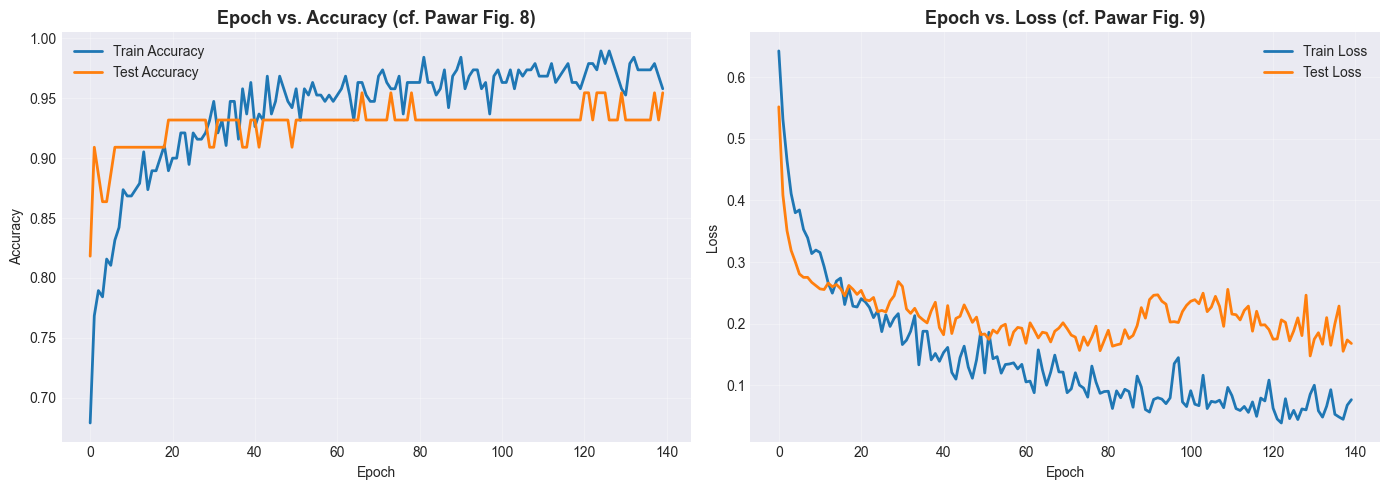

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy (Pawar Fig 8)
ax1.plot(history['accuracy'], label='Train Accuracy', lw=2)
ax1.plot(history['val_accuracy'], label='Test Accuracy', lw=2)
ax1.set_title('Epoch vs. Accuracy (cf. Pawar Fig. 8)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss (Pawar Fig 9)
ax2.plot(history['loss'], label='Train Loss', lw=2)
ax2.plot(history['val_loss'], label='Test Loss', lw=2)
ax2.set_title('Epoch vs. Loss (cf. Pawar Fig. 9)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Evaluation Metrics (cf. Pawar Table 3)

| Metric | Pawar et al. | Our Model |
|--------|-------------|------------|
| Accuracy | 0.9478 | ? |
| Precision | 0.7105 | ? |
| Recall | 0.8181 | ? |
| F1 Score | 0.7605 | ? |

In [12]:
# Predictions
model.eval()
with torch.no_grad():
    y_pred_prob = model(X_te_t).cpu().numpy()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_pred_prob) if len(np.unique(y_test)) > 1 else 0.0

print('='*60)
print('RESULTS COMPARISON — Pawar et al. vs Our Model')
print('='*60)
print(f'{"Metric":<15} {"Pawar et al.":>12} {"Our Model":>12}')
print('-'*42)
print(f'{"Accuracy":<15} {0.9478:>12.4f} {acc:>12.4f}')
print(f'{"Precision":<15} {0.7105:>12.4f} {prec:>12.4f}')
print(f'{"Recall":<15} {0.8181:>12.4f} {rec:>12.4f}')
print(f'{"F1 Score":<15} {0.7605:>12.4f} {f1:>12.4f}')
print(f'{"AUC":<15} {0.972:>12.3f} {auc:>12.3f}')
print('='*60)
print(f'\nNote: Pawar uses 24 features (accel+gyro), we use {n_features} features (accel only).')

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pothole']))

print('--- Confusion Matrix ---')
cm = confusion_matrix(y_test, y_pred)
print(cm)

RESULTS COMPARISON — Pawar et al. vs Our Model
Metric          Pawar et al.    Our Model
------------------------------------------
Accuracy              0.9478       0.9545
Precision             0.7105       1.0000
Recall                0.8181       0.9000
F1 Score              0.7605       0.9474
AUC                    0.972        0.994

Note: Pawar uses 24 features (accel+gyro), we use 16 features (accel only).

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96        24
     Pothole       1.00      0.90      0.95        20

    accuracy                           0.95        44
   macro avg       0.96      0.95      0.95        44
weighted avg       0.96      0.95      0.95        44

--- Confusion Matrix ---
[[24  0]
 [ 2 18]]


## 11. ROC-AUC Curve (cf. Pawar Figure 10)

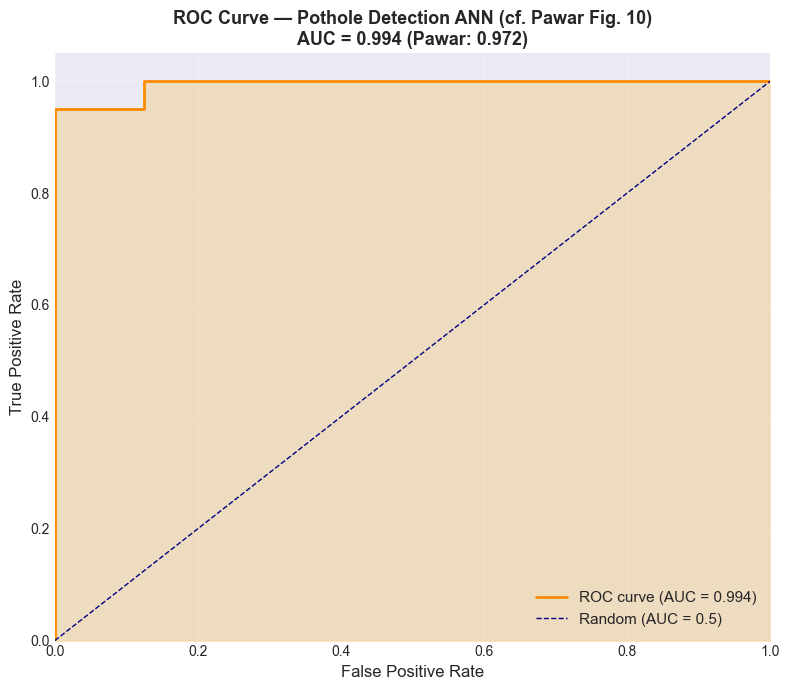

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.2, color='orange')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve — Pothole Detection ANN (cf. Pawar Fig. 10)\n'
             f'AUC = {auc:.3f} (Pawar: 0.972)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Confusion Matrix Visualization

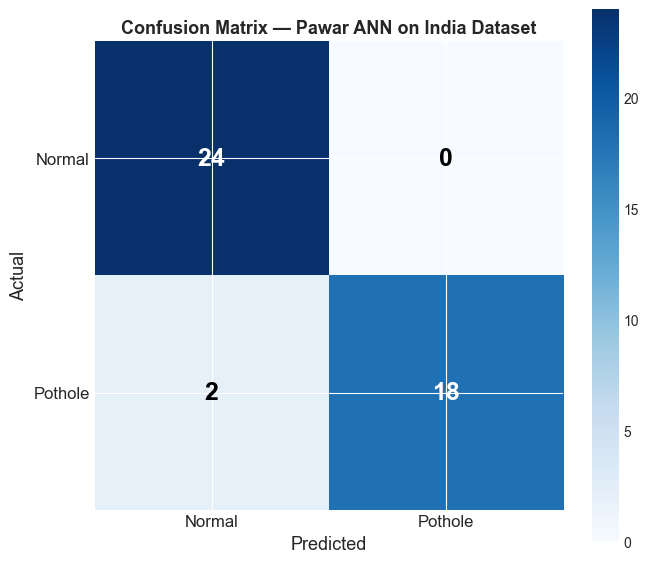

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')

labels = ['Normal', 'Pothole']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title('Confusion Matrix — Pawar ANN on India Dataset', fontsize=13, fontweight='bold')

# Annotate
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=18,
                fontweight='bold', color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 13. Feature Importance Analysis

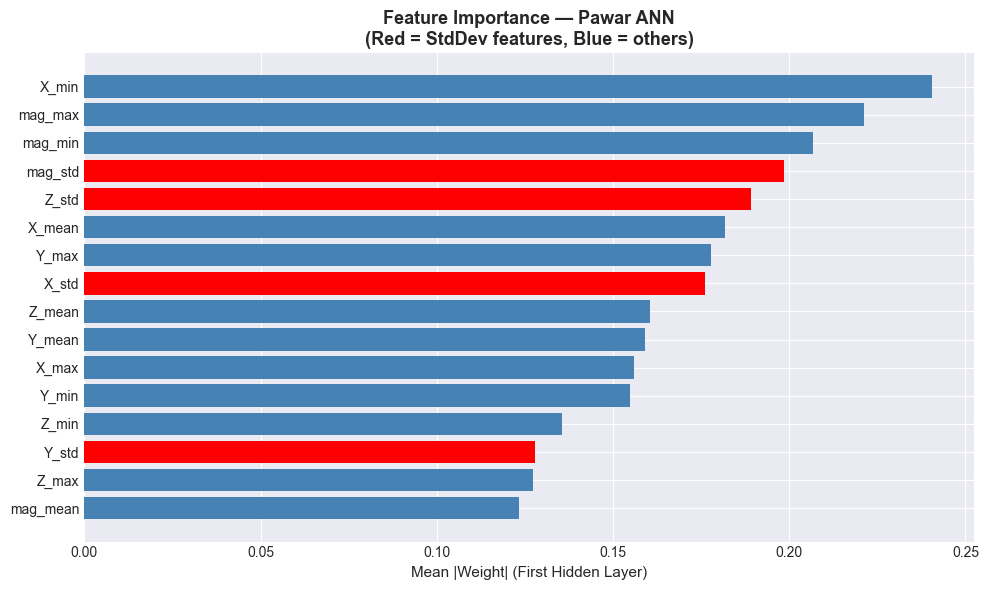


Top 5 most important features:
  1. X_min: 0.2404
  2. mag_max: 0.2213
  3. mag_min: 0.2067
  4. mag_std: 0.1984
  5. Z_std: 0.1891


In [15]:
# Use mean absolute weight from first hidden layer as feature importance proxy
w1 = list(model.net.parameters())[0].detach().cpu().numpy()  # shape: (64, n_features) 
importance = np.mean(np.abs(w1), axis=0)  # mean abs weight per feature

# Sort
idx = np.argsort(importance)[::-1]
sorted_features = [feature_cols[i] for i in idx]
sorted_importance = importance[idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if 'std' in f else 'steelblue' for f in sorted_features]
ax.barh(range(len(sorted_features)), sorted_importance, color=colors)
ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features)
ax.invert_yaxis()
ax.set_xlabel('Mean |Weight| (First Hidden Layer)', fontsize=11)
ax.set_title('Feature Importance — Pawar ANN\n(Red = StdDev features, Blue = others)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for i in range(min(5, len(sorted_features))):
    print(f'  {i+1}. {sorted_features[i]}: {sorted_importance[i]:.4f}')

## 14. Test Without SMOTE (Pawar "Expected" Model)

The paper also tested without SMOTE ("Expected" row in Table 3: acc=0.9263, prec=0.7368, rec=0.4242, F1=0.5384)

In [16]:
# Train without SMOTE for comparison
torch.manual_seed(42)
model_ns = PawarANN(n_features).to(device)

X_tr_ns = torch.FloatTensor(X_train_scaled).to(device)
y_tr_ns = torch.FloatTensor(y_train).to(device)
train_ds_ns = TensorDataset(X_tr_ns, y_tr_ns)
train_loader_ns = DataLoader(train_ds_ns, batch_size=BATCH_SIZE, shuffle=True)

criterion_ns = nn.BCELoss()
optimizer_ns = optim.Adam(model_ns.parameters())

for epoch in range(EPOCHS):
    model_ns.train()
    for xb, yb in train_loader_ns:
        pred = model_ns(xb)
        loss = criterion_ns(pred, yb)
        optimizer_ns.zero_grad()
        loss.backward()
        optimizer_ns.step()

model_ns.eval()
with torch.no_grad():
    y_pred_ns_prob = model_ns(X_te_t).cpu().numpy()
y_pred_ns = (y_pred_ns_prob >= 0.5).astype(int)

acc_ns = accuracy_score(y_test, y_pred_ns)
prec_ns = precision_score(y_test, y_pred_ns, zero_division=0)
rec_ns = recall_score(y_test, y_pred_ns, zero_division=0)
f1_ns = f1_score(y_test, y_pred_ns, zero_division=0)

print('='*65)
print('SMOTE vs No-SMOTE Comparison')
print('='*65)
print(f'{"":15} {"Pawar+SMOTE":>12} {"Pawar No-SMOTE":>15} {"Our+SMOTE":>12} {"Our No-SMOTE":>13}')
print('-'*68)
print(f'{"Accuracy":<15} {0.8957:>12.4f} {0.9263:>15.4f} {acc:>12.4f} {acc_ns:>13.4f}')
print(f'{"Precision":<15} {0.4864:>12.4f} {0.7368:>15.4f} {prec:>12.4f} {prec_ns:>13.4f}')
print(f'{"Recall":<15} {0.5454:>12.4f} {0.4242:>15.4f} {rec:>12.4f} {rec_ns:>13.4f}')
print(f'{"F1 Score":<15} {0.5142:>12.4f} {0.5384:>15.4f} {f1:>12.4f} {f1_ns:>13.4f}')
print('='*65)

SMOTE vs No-SMOTE Comparison
                 Pawar+SMOTE  Pawar No-SMOTE    Our+SMOTE  Our No-SMOTE
--------------------------------------------------------------------
Accuracy              0.8957          0.9263       0.9545        0.9318
Precision             0.4864          0.7368       1.0000        1.0000
Recall                0.5454          0.4242       0.9000        0.8500
F1 Score              0.5142          0.5384       0.9474        0.9189


## 15. Summary & Export

In [17]:
# Save windowed features
windowed.to_csv('pawar_windowed_features.csv', index=False)
print('Saved → pawar_windowed_features.csv')

# Save model 
torch.save(model.state_dict(), 'pawar_ann_model.pth')
print('Saved → pawar_ann_model.pth')

# Final summary
print('\n' + '='*60)
print('PAWAR et al. METHODOLOGY — REPLICATION SUMMARY')
print('='*60)
print(f'Dataset:      India_Data (10 trips)')
print(f'Samples:      {len(raw_data)} raw → {len(windowed)} windows (2-sec)')
print(f'Features:     {n_features} (Min/Max/Mean/StdDev × {n_features//4} axes)')
print(f'Class split:  {windowed["is_pothole"].sum()} pothole / {len(windowed)-windowed["is_pothole"].sum()} normal')
print(f'Model:        ANN (2 hidden Dense+Dropout + sigmoid output)')
print(f'Training:     {EPOCHS} epochs, batch_size={BATCH_SIZE}, SMOTE balanced')
print(f'\nResults:')
print(f'  Accuracy:   {acc:.4f} (Pawar: 0.9478)')
print(f'  Precision:  {prec:.4f} (Pawar: 0.7105)')
print(f'  Recall:     {rec:.4f} (Pawar: 0.8181)')
print(f'  F1 Score:   {f1:.4f} (Pawar: 0.7605)')
print(f'  AUC:        {auc:.3f} (Pawar: 0.972)')
print('='*60)

Saved → pawar_windowed_features.csv
Saved → pawar_ann_model.pth

PAWAR et al. METHODOLOGY — REPLICATION SUMMARY
Dataset:      India_Data (10 trips)
Samples:      3968 raw → 217 windows (2-sec)
Features:     16 (Min/Max/Mean/StdDev × 4 axes)
Class split:  98 pothole / 119 normal
Model:        ANN (2 hidden Dense+Dropout + sigmoid output)
Training:     140 epochs, batch_size=3, SMOTE balanced

Results:
  Accuracy:   0.9545 (Pawar: 0.9478)
  Precision:  1.0000 (Pawar: 0.7105)
  Recall:     0.9000 (Pawar: 0.8181)
  F1 Score:   0.9474 (Pawar: 0.7605)
  AUC:        0.994 (Pawar: 0.972)
